In [1]:
%pip install rasterio rioxarray pykrige scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import xarray as xr
import rioxarray as rxr
import pandas as pd
from sklearn.linear_model import LinearRegression
from pykrige.rk import RegressionKriging
import numpy as np


## Load DEM and Station Data

In [2]:
# Load high-resolution DEM with xarray.open_rasterio
dem = rxr.open_rasterio('sk_dem_small.tif')

dem = dem.sel(band=1)
dem = dem.where(dem != 0)
# Put variable name for dem
dem.name = "elev"

# Load station data
measurements = pd.read_csv("measurements.csv", sep=';')

In [3]:
measurements.head()

,City,ta_2m,lon,lat,elev
0,"Banská Bystrica, Slovakia",4.7,19.158581,48.738388,347.0
1,"Banská Štiavnica, Slovakia",2.8,18.898842,48.458092,570.0
2,"Bardejov, Slovakia",7.1,21.275602,49.292686,283.0
3,"Beluša, Slovakia",4.4,18.327969,49.065533,256.0
4,"Boľkovce, Slovakia",7.1,19.769983,48.337105,189.0


## Perform Regression Kriging

In [4]:
X = measurements[["lon", "lat"]].values

# PM: I think maybe you should only have elev here???
p = measurements[["lon", "lat", "elev"]].values
y = measurements[["ta_2m"]].values.ravel()

In [5]:
# Define regression model
reg_model = LinearRegression(n_jobs=-1)

# Initialize Regression Kriging with the chosen model
rk = RegressionKriging(
    method="universal",
    regression_model=reg_model,
    variogram_model="hole-effect",
    n_closest_points=10,
)

rk.fit(p=p, x=X, y=y)

Finished learning regression model
Finished kriging residuals


## Reshape Data and Predict Grid

In [8]:
dem

<xarray.DataArray 'elev' (y: 301, x: 701)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
    band         int32 4B 1
  * x            (x) float64 6kB 16.0 16.01 16.02 16.03 ... 22.98 22.99 23.0
  * y            (y) float64 2kB 50.0 49.99 49.98 49.97 ... 47.02 47.01 47.0
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     nan
    scale_factor:   1.0
    add_offset:     0.0

In [6]:

# Create grid of longitudes and latitudes
lonsi, latsi = np.meshgrid(dem.x, dem.y)

# Flatten the arrays
x_pred = np.array(list(zip(lonsi.ravel(), latsi.ravel())))

# Align dimension names with our station data
dem_renamed = dem.rename({"x": "lon", "y": "lat"})

# Convert the DataArray to Pandas DataFrame
p_pred = dem_renamed.to_dataframe().reset_index()[["lon", "lat", "elev"]]


In [14]:
# Predict and reshape predicted values
# Also handle nans in our DEM
predicted_values = rk.predict(x=x_pred, p=np.where(np.isnan(p_pred), 0, p_pred))
predicted_values = np.where(np.isnan(p_pred["elev"]), np.nan, predicted_values).reshape(lonsi.shape)

n_closest_points will be ignored for UniversalKriging


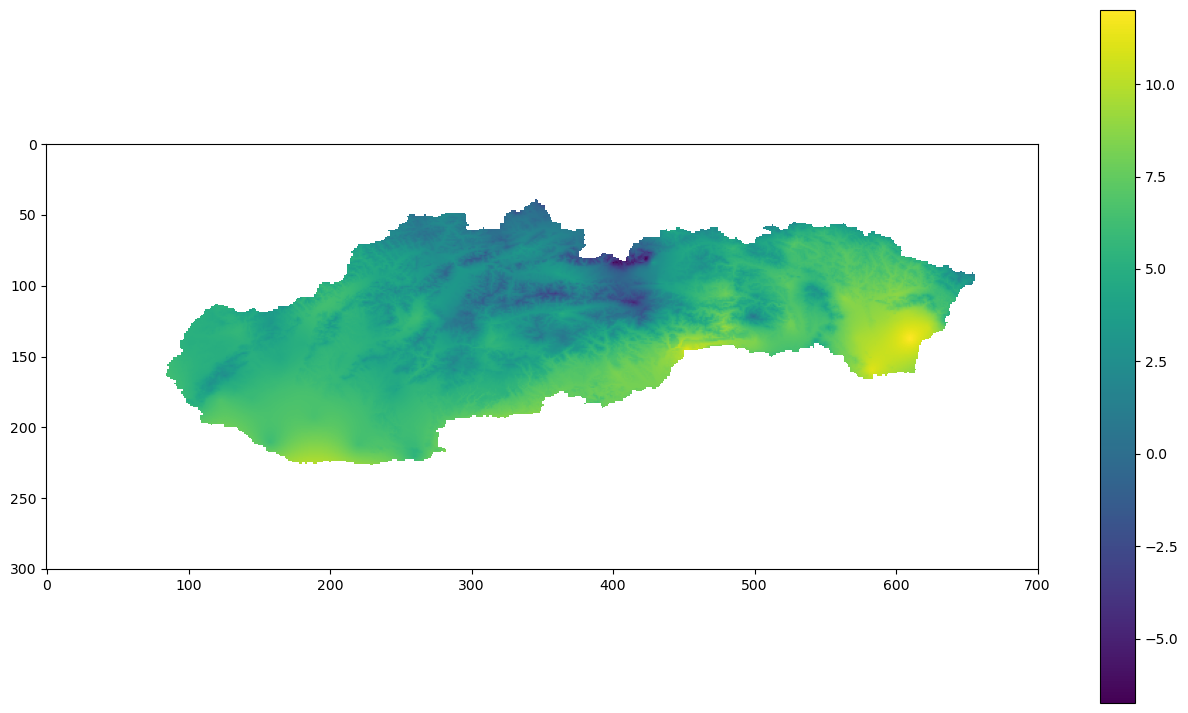

In [15]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(16,9))
plt.imshow(predicted_values)
plt.colorbar()
plt.show()

## Export Predicted values to .tif so we can visualize it in QGIS

In [10]:
predicted_da = xr.DataArray(
    predicted_values,
    coords=[("latitude", latsi[:, 0]), ("longitude", lonsi[0, :])],
)
predicted_da.rio.write_crs("epsg:4326", inplace=True)
predicted_da.rio.to_raster("interpolated_temperature.tif")